In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [ ]:
np.random.seed(42)
n = 500

engine_size = np.random.uniform(1.0, 5.0, n)

horsepower = 60 + engine_size * 40 + np.random.normal(0, 15, n)

weight = 900 + engine_size * 350 + np.random.normal(0, 100, n)

cylinders = np.clip(np.round(engine_size * 1.6), 3, 12)

mpg = 45 - engine_size * 4 - weight * 0.005 - horsepower * 0.03 + np.random.normal(0, 1.5, n)

mpg = np.clip(mpg, 8, 45)

car_df = pd.DataFrame({
    "engine_size_L": engine_size,
    "horsepower": horsepower,
    "weight_kg": weight,
    "cylinders": cylinders,
    "mpg": mpg
})

car_df.head()

,engine_size_L,horsepower,weight_kg,cylinders,mpg
0,2.498160,165.052759,1832.748985,4.0,22.844642
1,4.802857,280.256852,2545.070820,8.0,8.000000
2,3.927976,231.375388,2333.857002,6.0,10.725556
3,3.394634,187.131803,2198.992236,5.0,13.682422
4,1.624075,111.486762,1550.474315,3.0,28.096686


In [ ]:
car_df = pd.DataFrame({
    "engine_size_L": engine_size,
    "horsepower": horsepower,
    "weight_kg": weight,
    "cylinders": cylinders,
    "mpg": mpg
})

car_df.head()

,engine_size_L,horsepower,weight_kg,cylinders,mpg
0,2.498160,165.052759,1832.748985,4.0,22.844642
1,4.802857,280.256852,2545.070820,8.0,8.000000
2,3.927976,231.375388,2333.857002,6.0,10.725556
3,3.394634,187.131803,2198.992236,5.0,13.682422
4,1.624075,111.486762,1550.474315,3.0,28.096686


In [ ]:
car_df.shape

(500, 5)

In [ ]:
car_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   engine_size_L  500 non-null    float64
 1   horsepower     500 non-null    float64
 2   weight_kg      500 non-null    float64
 3   cylinders      500 non-null    float64
 4   mpg            500 non-null    float64
dtypes: float64(5)
memory usage: 19.7 KB


In [ ]:
X = car_df.drop(columns=["mpg"])
y = car_df["mpg"]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
lr = LinearRegression()

In [ ]:
lr.fit(X_train, y_train)

LinearRegression()

In [ ]:
rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

In [ ]:
rf.fit(X_train, y_train)

RandomForestRegressor(n_estimators=200, random_state=42)

In [ ]:
lr_predictions = lr.predict(X_test)

print(lr_predictions[:10])

[15.37894427 10.51927246 29.62835695 25.34127132  7.47881308 22.24641763
 31.5547261  24.35150237 29.82118431 11.07870707]


In [ ]:
rf_predictions = rf.predict(X_test)

print(rf_predictions[:10])

[14.45309321  9.97983315 30.09557181 26.30077552  8.0069761  21.3527649
 31.25689122 25.17097382 30.9148468   9.65036968]


In [ ]:
lr_mae = mean_absolute_error(y_test, lr_predictions)

print("Linear Regression MAE:", lr_mae)

Linear Regression MAE: 1.2710921270876328


In [ ]:
lr_rmse = mean_squared_error(y_test, lr_predictions) ** 0.5

print("Linear Regression RMSE:", lr_rmse)

Linear Regression RMSE: 1.5684526079667955


In [ ]:
lr_r2 = r2_score(y_test, lr_predictions)

print("Linear Regression R2:", lr_r2)

Linear Regression R2: 0.9615608929031741


In [ ]:
rf_mae = mean_absolute_error(y_test, rf_predictions)

print("Random Forest MAE:", rf_mae)

Random Forest MAE: 1.1709153427359311


In [ ]:
rf_rmse = mean_squared_error(y_test, rf_predictions) ** 0.5

print("Random Forest RMSE:", rf_rmse)

Random Forest RMSE: 1.5319467255568493


In [ ]:
rf_r2 = r2_score(y_test, rf_predictions)

print("Random Forest R2:", rf_r2)

Random Forest R2: 0.9633294169727016


In [ ]:
results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "MAE": [lr_mae, rf_mae],
    "RMSE": [lr_rmse, rf_rmse],
    "R2": [lr_r2, rf_r2]
})

results

,Model,MAE,RMSE,R2
0,Linear Regression,1.271092,1.568453,0.961561
1,Random Forest,1.170915,1.531947,0.963329


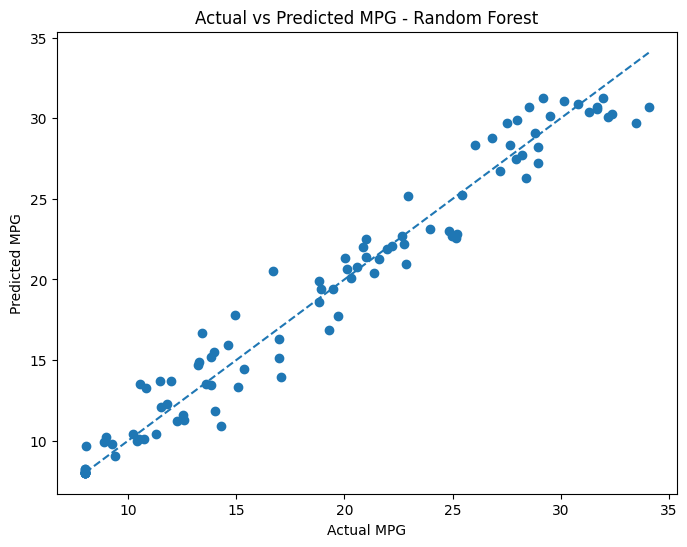

In [ ]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test, rf_predictions)

plt.xlabel("Actual MPG")
plt.ylabel("Predicted MPG")

plt.title("Actual vs Predicted MPG - Random Forest")

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.show()

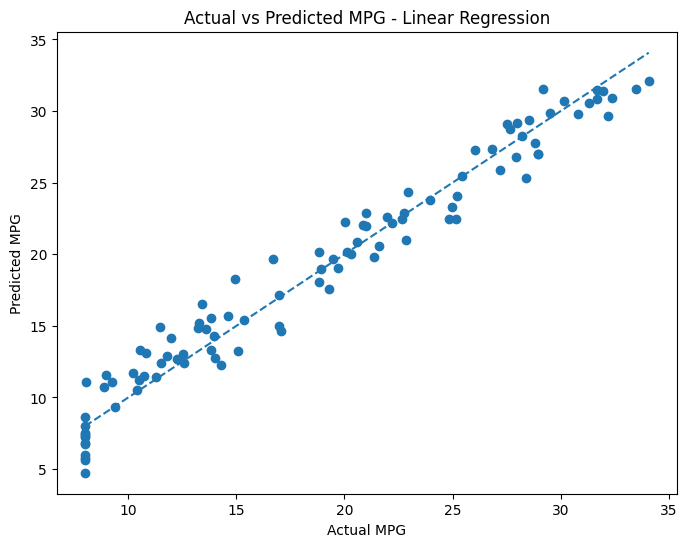

In [ ]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test, lr_predictions)

plt.xlabel("Actual MPG")
plt.ylabel("Predicted MPG")

plt.title("Actual vs Predicted MPG - Linear Regression")

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.show()